Benchmark Toàn Diện + Báo Cáo


In [1]:
import sys, os
from pathlib import Path

# notebooks/ nằm trong root/notebooks/
# → root = parent của notebooks/
notebook_dir = Path.cwd()
root = notebook_dir.parent if (notebook_dir.parent / 'src').exists() else notebook_dir

# Thêm src/ vào sys.path để import được modules
sys.path.insert(0, str(root / 'src'))

# Tạo output folders
os.makedirs(root / 'results' / 'figures', exist_ok=True)

print(f'✓ root  : {root}')
print(f'✓ src/  : {root / "src"} — exists: {(root / "src").exists()}')
print(f'✓ results/ created')

✓ root  : w:\Denoise Project\classic_image_denoising_benchmark
✓ src/  : w:\Denoise Project\classic_image_denoising_benchmark\src — exists: True
✓ results/ created


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings('ignore')

from skimage import data as skdata
from noise import add_gaussian_noise
from filters import gaussian_filter, median_filter
from metrics import psnr, ssim
print('✓ imports OK')

✓ imports OK


In [3]:
# ── Load dataset ──────────────────────────────────────────────────
images = {
    'camera'    : skdata.camera(),
    'astronaut' : skdata.astronaut()[:,:,0],
    'coins'     : skdata.coins(),
    'clock'     : skdata.clock(),
    'page'      : skdata.page(),
    'horse'     : (skdata.horse().astype(np.uint8) * 255),
    'chelsea'   : skdata.chelsea()[:,:,0],
    'coffee'    : skdata.coffee()[:,:,0],
    'moon'      : skdata.moon(),
    'text'      : skdata.text(),
    'brick'     : skdata.brick(),
    'grass'     : skdata.grass(),
}
print(f'✓ Loaded {len(images)} images')
for name, img in list(images.items())[:3]:
    print(f'  {name}: {img.shape}')

✓ Loaded 12 images
  camera: (512, 512)
  astronaut: (512, 512)
  coins: (303, 384)


In [4]:
# ── Load methods ──────────────────────────────────────────────────
from nlm import nlm_denoise_fast
from bm3d_wrapper import bm3d_denoise

methods = {
    'Gaussian' : lambda img, s: gaussian_filter(img, 5, 1.5),
    'Median'   : lambda img, s: median_filter(img, 3),
    'NLM'      : lambda img, s: nlm_denoise_fast(img, h=s),
    'BM3D'     : lambda img, s: bm3d_denoise(img, sigma_psd=s),
}

# Optional: K-SVD (slow)
try:
    from ksvd_denoising import ksvd_denoise
    def run_ksvd(img, s):
        r, _, _ = ksvd_denoise(img, dict_size=128, patch_size=8, iterations=5, sparsity=3)
        return r
    methods['KSVD'] = run_ksvd
    print('✓ K-SVD loaded')
except:
    print('⚠ K-SVD skipped')

SIGMAS = [15, 25, 50]
print(f'\n✓ Methods: {list(methods.keys())}')
print(f'✓ Sigmas: {SIGMAS}')

✓ K-SVD loaded

✓ Methods: ['Gaussian', 'Median', 'NLM', 'BM3D', 'KSVD']
✓ Sigmas: [15, 25, 50]


In [5]:
# ── Run Benchmark ─────────────────────────────────────────────────
# Tuỳ chọn: SKIP_KSVD=True để nhanh
SKIP_KSVD = True   # <── Đặt False để chạy K-SVD (chậm)

records = []
method_list = {k: v for k, v in methods.items() if not (SKIP_KSVD and k == 'KSVD')}

total = len(images) * len(SIGMAS) * len(method_list)
done = 0

for img_name, img in images.items():
    img = img.astype(np.uint8)
    for sigma in SIGMAS:
        noisy = add_gaussian_noise(img, sigma=sigma)

        # Baseline
        records.append(dict(image=img_name, method='Noisy', sigma=sigma,
                            psnr=round(psnr(img,noisy),4),
                            ssim=round(ssim(img,noisy),6), runtime_ms=0))

        for method_name, fn in method_list.items():
            done += 1
            t0 = time.perf_counter()
            result = fn(noisy, sigma)
            rt = round((time.perf_counter() - t0)*1000, 1)

            result = np.clip(result, 0, 255).astype(np.uint8)
            p = round(psnr(img, result), 4)
            s = round(ssim(img, result), 6)

            records.append(dict(image=img_name, method=method_name,
                                sigma=sigma, psnr=p, ssim=s, runtime_ms=rt))

            print(f'[{done:3d}/{total}] {img_name:12s} | {method_name:8s} | σ={sigma:2d} | '
                  f'PSNR={p:.2f} dB | {rt:.0f}ms')

df = pd.DataFrame(records)
df.to_csv(str(root / 'results' / 'benchmark_raw.csv'), index=False)
print(f'\n✓ Saved: results/benchmark_raw.csv  ({len(df)} rows)')

[  1/144] camera       | Gaussian | σ=15 | PSNR=27.53 dB | 1154ms
[  2/144] camera       | Median   | σ=15 | PSNR=28.13 dB | 2680ms
[  3/144] camera       | NLM      | σ=15 | PSNR=29.79 dB | 654ms
[  4/144] camera       | BM3D     | σ=15 | PSNR=31.83 dB | 4149ms
[  5/144] camera       | Gaussian | σ=25 | PSNR=26.79 dB | 1877ms
[  6/144] camera       | Median   | σ=25 | PSNR=25.84 dB | 4596ms
[  7/144] camera       | NLM      | σ=25 | PSNR=28.15 dB | 1035ms
[  8/144] camera       | BM3D     | σ=25 | PSNR=29.70 dB | 3486ms
[  9/144] camera       | Gaussian | σ=50 | PSNR=24.21 dB | 1864ms
[ 10/144] camera       | Median   | σ=50 | PSNR=21.49 dB | 4639ms
[ 11/144] camera       | NLM      | σ=50 | PSNR=24.80 dB | 1180ms
[ 12/144] camera       | BM3D     | σ=50 | PSNR=26.72 dB | 3612ms
[ 13/144] astronaut    | Gaussian | σ=15 | PSNR=27.50 dB | 1126ms
[ 14/144] astronaut    | Median   | σ=15 | PSNR=29.16 dB | 2730ms
[ 15/144] astronaut    | NLM      | σ=15 | PSNR=31.38 dB | 598ms
[ 16/144] as

[01/12] Create grid camera       | σ=15


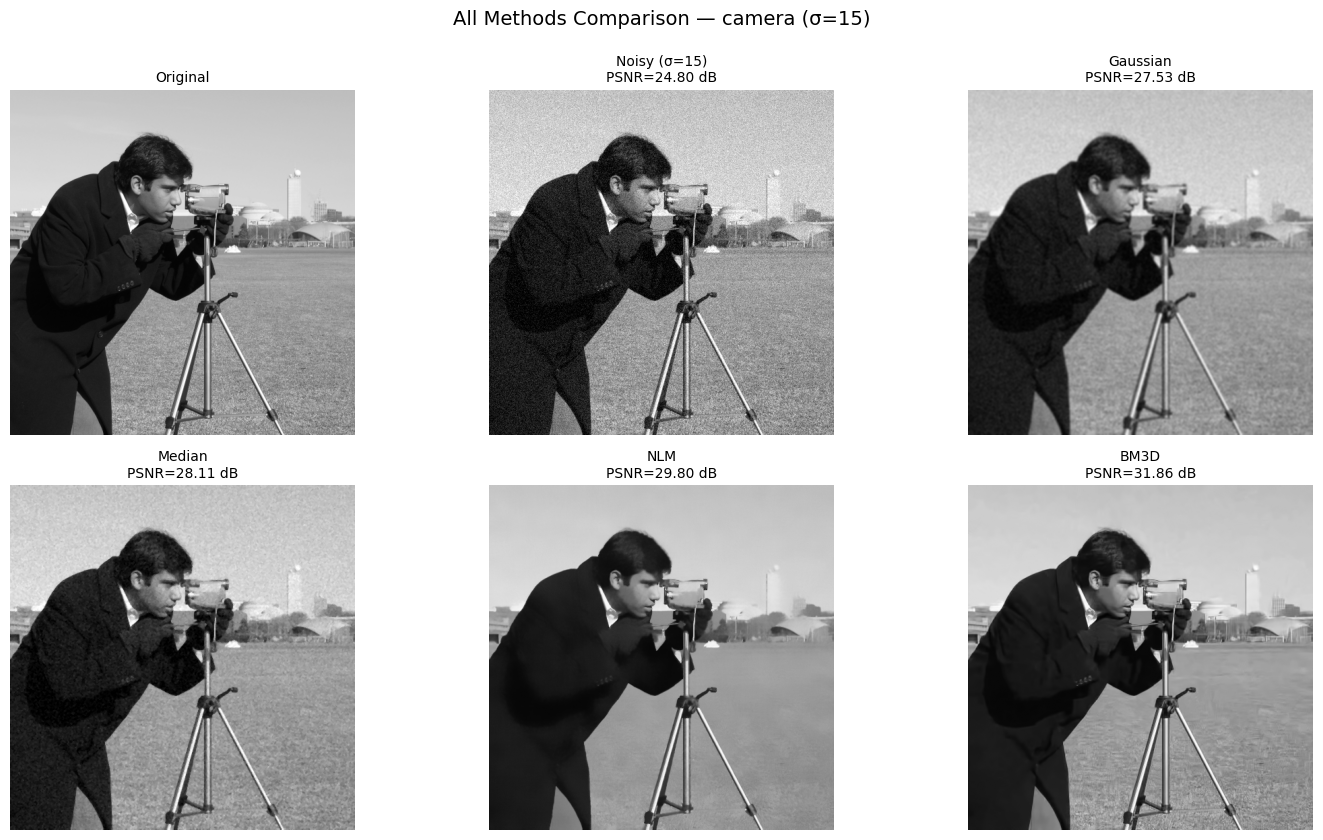

[01/12] Create grid camera       | σ=25
[01/12] Create grid camera       | σ=50
[02/12] Create grid astronaut    | σ=15
[02/12] Create grid astronaut    | σ=25
[02/12] Create grid astronaut    | σ=50
[03/12] Create grid coins        | σ=15
[03/12] Create grid coins        | σ=25
[03/12] Create grid coins        | σ=50
[04/12] Create grid clock        | σ=15
[04/12] Create grid clock        | σ=25
[04/12] Create grid clock        | σ=50
[05/12] Create grid page         | σ=15
[05/12] Create grid page         | σ=25
[05/12] Create grid page         | σ=50
[06/12] Create grid horse        | σ=15
[06/12] Create grid horse        | σ=25
[06/12] Create grid horse        | σ=50
[07/12] Create grid chelsea      | σ=15
[07/12] Create grid chelsea      | σ=25
[07/12] Create grid chelsea      | σ=50
[08/12] Create grid coffee       | σ=15
[08/12] Create grid coffee       | σ=25
[08/12] Create grid coffee       | σ=50
[09/12] Create grid moon         | σ=15
[09/12] Create grid moon         | σ=25


,image,sigma,path,num_panels,methods
0,camera,15,results\comparison_grids\camera_sigma_15_compa...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
1,camera,25,results\comparison_grids\camera_sigma_25_compa...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
2,camera,50,results\comparison_grids\camera_sigma_50_compa...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
3,astronaut,15,results\comparison_grids\astronaut_sigma_15_co...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
4,astronaut,25,results\comparison_grids\astronaut_sigma_25_co...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
5,astronaut,50,results\comparison_grids\astronaut_sigma_50_co...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
6,coins,15,results\comparison_grids\coins_sigma_15_compar...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
7,coins,25,results\comparison_grids\coins_sigma_25_compar...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
8,coins,50,results\comparison_grids\coins_sigma_50_compar...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"
9,clock,15,results\comparison_grids\clock_sigma_15_compar...,6,"Original, Noisy, Gaussian, Median, NLM, BM3D"


In [6]:
# ── Export composite denoise comparison grids ───────────────────────
# Cell này xuất 1 ảnh tổng hợp cho từng ảnh gốc và từng mức noise σ.
# Mỗi ảnh tổng hợp gồm: Original, Noisy, Gaussian, Median, NLM, BM3D, ...
# Output ví dụ:
#   results/comparison_grids/camera_sigma_25_comparison.png

from pathlib import Path
import math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COMPOSITE_DIR = root / 'results' / 'comparison_grids'
COMPOSITE_DIR.mkdir(parents=True, exist_ok=True)

# Có thể chỉnh 3 dòng này nếu muốn export nhanh hơn
COMPOSITE_IMAGES = images          # ví dụ: {'camera': images['camera'], 'moon': images['moon']}
COMPOSITE_SIGMAS = SIGMAS          # ví dụ: [25]
COMPOSITE_METHODS = method_list    # đang tôn trọng SKIP_KSVD ở cell benchmark
COMPOSITE_SEED = 42                # seed cố định để kết quả export lặp lại giống nhau
SHOW_FIRST_GRID = True             # chỉ hiển thị preview ảnh tổng hợp đầu tiên trong notebook

np.random.seed(COMPOSITE_SEED)

def safe_name(text):
    """Đổi tên ảnh/method thành dạng an toàn để đặt filename."""
    return re.sub(r'[^a-zA-Z0-9_-]+', '_', str(text)).strip('_').lower()

def to_uint8(arr):
    """Ép ảnh về uint8 [0, 255]."""
    return np.clip(arr, 0, 255).astype(np.uint8)

def show_img(ax, arr, title):
    """Hiển thị ảnh grayscale/RGB đúng kiểu."""
    arr = to_uint8(arr)
    if arr.ndim == 2:
        ax.imshow(arr, cmap='gray', vmin=0, vmax=255)
    else:
        ax.imshow(arr)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

composite_manifest = []
composite_metrics = []

for image_idx, (img_name, img) in enumerate(COMPOSITE_IMAGES.items(), start=1):
    clean = to_uint8(img)

    for sigma in COMPOSITE_SIGMAS:
        noisy = to_uint8(add_gaussian_noise(clean, sigma=sigma))

        # Gom tất cả ảnh cần vẽ vào list theo đúng thứ tự
        panels = []
        panels.append(('Original', clean, None, None, None))
        panels.append(('Noisy', noisy, psnr(clean, noisy), ssim(clean, noisy), 0.0))

        print(f'[{image_idx:02d}/{len(COMPOSITE_IMAGES):02d}] Create grid {img_name:12s} | σ={sigma}')

        for method_name, fn in COMPOSITE_METHODS.items():
            t0 = time.perf_counter()
            result = to_uint8(fn(noisy, sigma))
            runtime_ms = (time.perf_counter() - t0) * 1000

            p = psnr(clean, result)
            q = ssim(clean, result)
            panels.append((method_name, result, p, q, runtime_ms))

            composite_metrics.append({
                'image': img_name,
                'sigma': sigma,
                'method': method_name,
                'psnr': round(p, 4),
                'ssim': round(q, 6),
                'runtime_ms': round(runtime_ms, 1)
            })

        # Layout giống ảnh ví dụ: 3 cột, tự tăng số dòng
        n_panels = len(panels)
        n_cols = 3
        n_rows = math.ceil(n_panels / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.2 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, (name, arr, p, q, runtime_ms) in zip(axes, panels):
            if name == 'Original':
                title = 'Original'
            elif name == 'Noisy':
                title = f'Noisy (σ={sigma})\nPSNR={p:.2f} dB'
            else:
                title = f'{name}\nPSNR={p:.2f} dB'
            show_img(ax, arr, title)

        # Ẩn ô trống nếu số ảnh không chia hết cho 3
        for ax in axes[n_panels:]:
            ax.axis('off')

        fig.suptitle(f'All Methods Comparison — {img_name} (σ={sigma})', fontsize=14, y=0.995)
        fig.tight_layout()

        out_path = COMPOSITE_DIR / f'{safe_name(img_name)}_sigma_{sigma}_comparison.png'
        fig.savefig(out_path, dpi=150, bbox_inches='tight')

        composite_manifest.append({
            'image': img_name,
            'sigma': sigma,
            'path': str(out_path.relative_to(root)),
            'num_panels': n_panels,
            'methods': ', '.join([p[0] for p in panels])
        })

        if SHOW_FIRST_GRID and len(composite_manifest) == 1:
            plt.show()
        else:
            plt.close(fig)

# Lưu file CSV để biết ảnh tổng hợp nằm ở đâu
manifest_df = pd.DataFrame(composite_manifest)
metrics_df = pd.DataFrame(composite_metrics)

manifest_csv = COMPOSITE_DIR / 'comparison_manifest.csv'
metrics_csv = COMPOSITE_DIR / 'comparison_metrics.csv'
manifest_df.to_csv(manifest_csv, index=False)
metrics_df.to_csv(metrics_csv, index=False)

print(f'\n✓ Exported {len(manifest_df)} composite images')
print(f'✓ Composite folder : {COMPOSITE_DIR}')
print(f'✓ Manifest CSV     : {manifest_csv}')
print(f'✓ Metrics CSV      : {metrics_csv}')
display(manifest_df.head(20))



In [7]:
# ── Summary Table ─────────────────────────────────────────────────
summary = (df.groupby(['method','sigma'])
             .agg(psnr_mean=('psnr','mean'), ssim_mean=('ssim','mean'),
                  runtime_mean=('runtime_ms','mean'))
             .round(3).reset_index())

ORDER = ['Noisy','Gaussian','Median','NLM','BM3D','KSVD']
present = [m for m in ORDER if m in summary['method'].unique()]

for metric, label in [('psnr_mean','PSNR (dB)'), ('ssim_mean','SSIM')]:
    pivot = summary.pivot(index='method', columns='sigma', values=metric).reindex(present)
    print(f'\n{"="*50}')
    print(f'{label}')
    print('='*50)
    print(pivot.round(2).to_string())

summary.to_csv(str(root / 'results' / 'benchmark_summary.csv'), index=False)


PSNR (dB)
sigma        15     25     50
method                       
Noisy     24.94  20.58  14.93
Gaussian  27.87  26.63  23.76
Median    28.60  25.93  21.33
NLM       31.20  28.27  24.50
BM3D      33.52  30.97  27.08

SSIM
sigma       15    25    50
method                    
Noisy     0.49  0.33  0.18
Gaussian  0.77  0.70  0.52
Median    0.72  0.56  0.34
NLM       0.83  0.77  0.63
BM3D      0.90  0.85  0.76


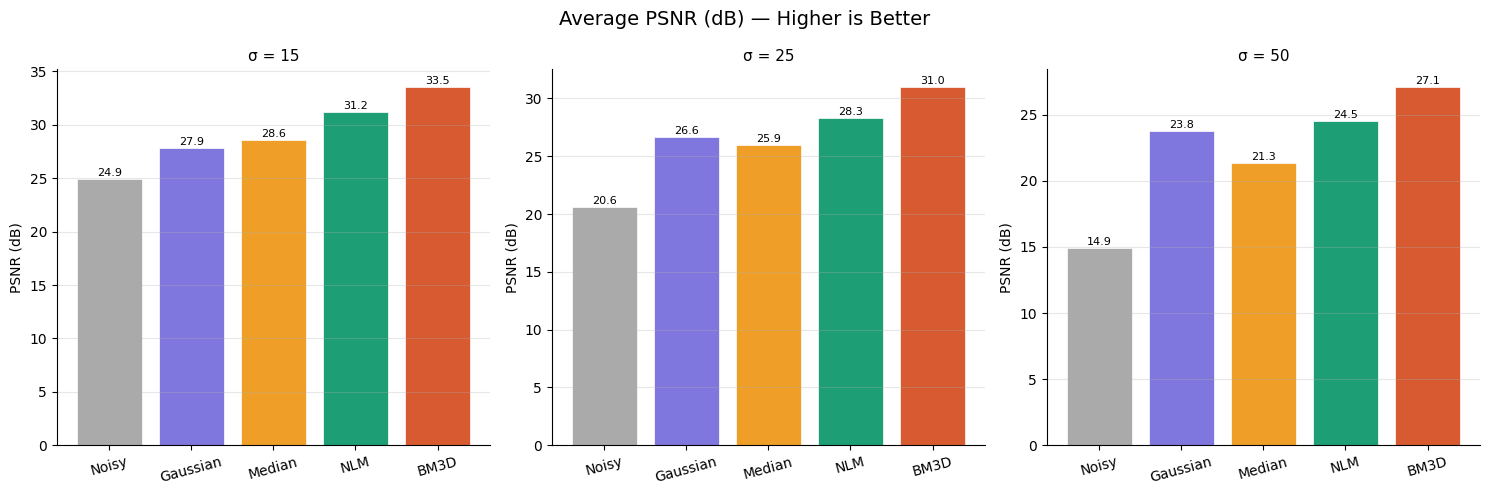

✓ Saved 01_psnr_bars.png


In [8]:
# ── Plot 1: PSNR Grouped Bar Charts ───────────────────────────────
COLORS = {'Noisy':'#aaa','Gaussian':'#7F77DD','Median':'#EF9F27',
          'NLM':'#1D9E75','BM3D':'#D85A30','KSVD':'#378ADD'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Average PSNR (dB) — Higher is Better', fontsize=14)

for ax, sigma in zip(axes, SIGMAS):
    sub = summary[summary['sigma']==sigma].set_index('method').reindex(present)
    vals = sub['psnr_mean'].values
    colors = [COLORS.get(m,'#888') for m in present]
    bars = ax.bar(present, vals, color=colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_title(f'σ = {sigma}', fontsize=11)
    ax.set_ylabel('PSNR (dB)'); ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(str(root/'results'/'figures'/'01_psnr_bars.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 01_psnr_bars.png')

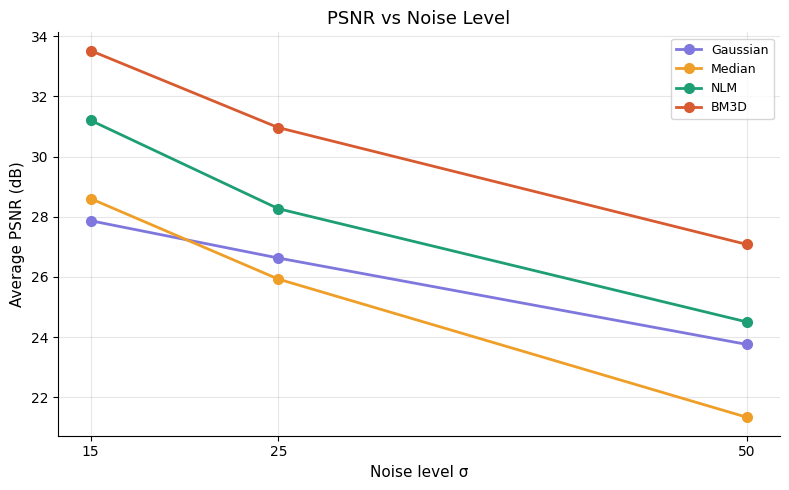

✓ Saved 02_psnr_vs_sigma.png


In [9]:
# ── Plot 2: PSNR vs Sigma Line ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for m in [m for m in present if m != 'Noisy']:
    sub = summary[summary['method']==m].sort_values('sigma')
    ax.plot(sub['sigma'], sub['psnr_mean'], 'o-',
            color=COLORS.get(m,'#888'), label=m, linewidth=2, markersize=7)

ax.set_xlabel('Noise level σ', fontsize=11)
ax.set_ylabel('Average PSNR (dB)', fontsize=11)
ax.set_title('PSNR vs Noise Level', fontsize=13)
ax.set_xticks(SIGMAS); ax.legend(fontsize=9)
ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(root/'results'/'figures'/'02_psnr_vs_sigma.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 02_psnr_vs_sigma.png')

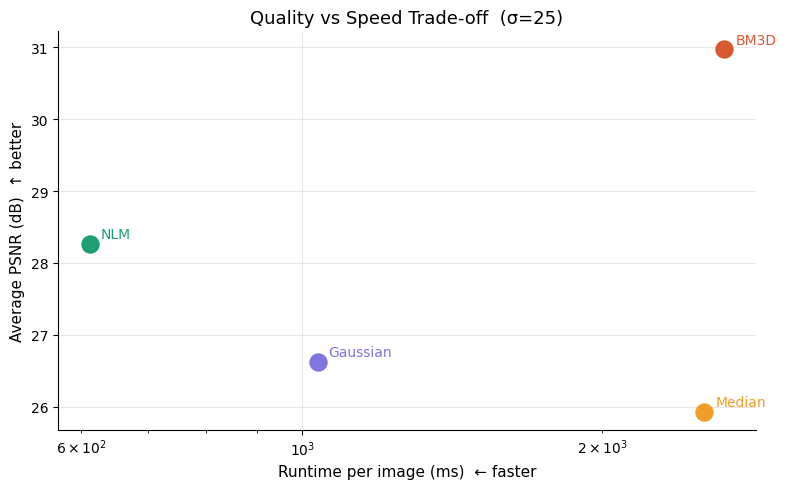

✓ Saved 03_tradeoff.png


In [10]:
# ── Plot 3: Quality vs Speed Trade-off ────────────────────────────
sigma_tradeoff = 25
methods_tradeoff = [m for m in present if m != 'Noisy']
sub = (df[df['sigma']==sigma_tradeoff]
       .groupby('method')
       .agg(psnr_mean=('psnr','mean'), rt=('runtime_ms','mean'))
       .reindex(methods_tradeoff).dropna())

fig, ax = plt.subplots(figsize=(8, 5))
for method, row in sub.iterrows():
    c = COLORS.get(method,'#888')
    ax.scatter(row['rt'], row['psnr_mean'], color=c, s=150, zorder=5)
    ax.annotate(method, xy=(row['rt'], row['psnr_mean']),
                xytext=(8,4), textcoords='offset points', fontsize=10, color=c)

ax.set_xlabel('Runtime per image (ms)  ← faster', fontsize=11)
ax.set_ylabel('Average PSNR (dB)  ↑ better', fontsize=11)
ax.set_title(f'Quality vs Speed Trade-off  (σ={sigma_tradeoff})', fontsize=13)
ax.set_xscale('log')
ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(root/'results'/'figures'/'03_tradeoff.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 03_tradeoff.png')

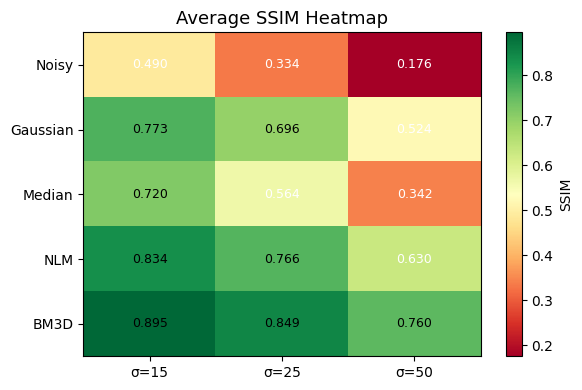

✓ Saved 04_ssim_heatmap.png


In [11]:
# ── Plot 4: SSIM Heatmap ───────────────────────────────────────────
matrix = np.full((len(present), len(SIGMAS)), np.nan)
for i, m in enumerate(present):
    for j, s in enumerate(SIGMAS):
        v = summary[(summary['method']==m) & (summary['sigma']==s)]['ssim_mean'].values
        if len(v): matrix[i,j] = v[0]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto',
               vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))
ax.set_xticks(range(len(SIGMAS))); ax.set_xticklabels([f'σ={s}' for s in SIGMAS])
ax.set_yticks(range(len(present))); ax.set_yticklabels(present)
ax.set_title('Average SSIM Heatmap', fontsize=13)
for i in range(len(present)):
    for j in range(len(SIGMAS)):
        v = matrix[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                    color='white' if v < 0.65 else 'black')
plt.colorbar(im, ax=ax, label='SSIM')
plt.tight_layout()
plt.savefig(str(root/'results'/'figures'/'04_ssim_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 04_ssim_heatmap.png')

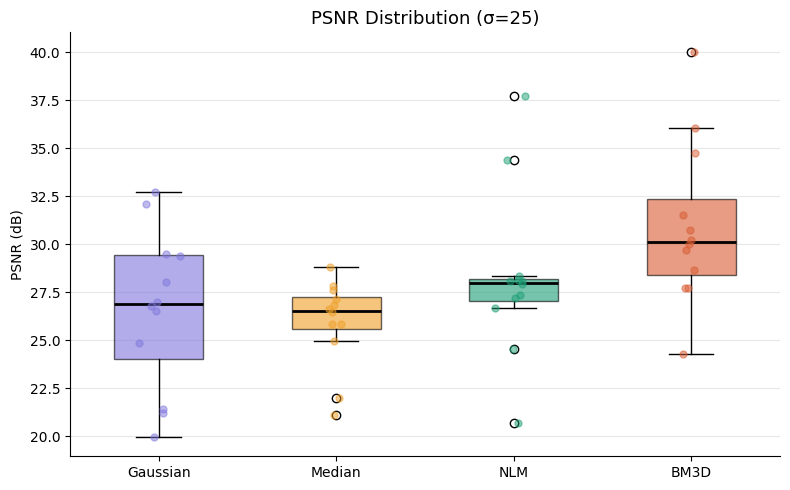

✓ Saved 05_boxplot.png


In [12]:
# ── Plot 5: Boxplot per method ─────────────────────────────────────
sigma_box = 25
methods_box = [m for m in present if m != 'Noisy']
sub = df[df['sigma']==sigma_box]

data_vals = [sub[sub['method']==m]['psnr'].dropna().values for m in methods_box]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_vals, patch_artist=True, widths=0.5,
                medianprops=dict(color='black',linewidth=2))
for patch, m in zip(bp['boxes'], methods_box):
    patch.set_facecolor(COLORS.get(m,'#888')); patch.set_alpha(0.6)
for i, (d, m) in enumerate(zip(data_vals, methods_box)):
    ax.scatter(np.random.normal(i+1,0.05,len(d)), d,
               color=COLORS.get(m,'#888'), alpha=0.5, s=25, zorder=5)
ax.set_xticks(range(1,len(methods_box)+1)); ax.set_xticklabels(methods_box)
ax.set_ylabel('PSNR (dB)'); ax.set_title(f'PSNR Distribution (σ={sigma_box})', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(str(root/'results'/'figures'/'05_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 05_boxplot.png')

In [13]:
# ── Final Summary ──────────────────────────────────────────────────
print('='*60)
print('WEEK 4 BENCHMARK — COMPLETE RESULTS')
print('='*60)
for sigma in SIGMAS:
    print(f'\nσ = {sigma}:')
    sub = summary[summary['sigma']==sigma].set_index('method').reindex(present)
    for m in present:
        row = sub.loc[m]
        if not np.isnan(row['psnr_mean']):
            star = ' ★' if row['psnr_mean'] == sub['psnr_mean'].max() and m != 'Noisy' else ''
            print(f'  {m:10s}  PSNR={row["psnr_mean"]:.2f} dB  '
                  f'SSIM={row["ssim_mean"]:.4f}  {row["runtime_mean"]:.0f}ms{star}')
print('\n✓ All figures in results/figures/')

WEEK 4 BENCHMARK — COMPLETE RESULTS

σ = 15:
  Noisy       PSNR=24.93 dB  SSIM=0.4900  0ms
  Gaussian    PSNR=27.87 dB  SSIM=0.7730  958ms
  Median      PSNR=28.60 dB  SSIM=0.7200  2278ms
  NLM         PSNR=31.20 dB  SSIM=0.8340  523ms
  BM3D        PSNR=33.52 dB  SSIM=0.8950  2486ms ★

σ = 25:
  Noisy       PSNR=20.58 dB  SSIM=0.3340  0ms
  Gaussian    PSNR=26.63 dB  SSIM=0.6960  1036ms
  Median      PSNR=25.93 dB  SSIM=0.5640  2531ms
  NLM         PSNR=28.27 dB  SSIM=0.7660  612ms
  BM3D        PSNR=30.97 dB  SSIM=0.8490  2651ms ★

σ = 50:
  Noisy       PSNR=14.93 dB  SSIM=0.1760  0ms
  Gaussian    PSNR=23.76 dB  SSIM=0.5240  1040ms
  Median      PSNR=21.33 dB  SSIM=0.3420  2524ms
  NLM         PSNR=24.50 dB  SSIM=0.6300  598ms
  BM3D        PSNR=27.08 dB  SSIM=0.7600  2343ms ★

✓ All figures in results/figures/
